# P_143 — Bank Branch Performance Analysis

## Objective

Analyze bank branch performance using financial,
customer, and operational data.

## Key Business Questions

1. Which branches are performing well?
2. Which branches are underperforming?
3. Which branches generate the highest profit?
4. How efficiently are branches operating?
5. Which branches have high complaint rates?
6. What factors are associated with branch performance?
7. What are customers saying about branch services?

## Main KPI Categories

### Financial
- Revenue
- Expenses
- Profit
- Profit Margin
- Deposits
- Loans

### Customer
- Total Customers
- New Customers
- Complaints
- Customer Satisfaction

### Operational
- Employees
- Transactions
- Revenue per Employee
- Customers per Employee

### NLP
- Customer Sentiment
- Complaint Category
- Common Customer Issues

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("P_143 Bank Branch Analytics")
print("Environment setup successful!")

P_143 Bank Branch Analytics
Environment setup successful!


# Expected Dataset Structure

| Column | Description |
|---|---|
| Branch_ID | Unique branch identifier |
| Branch_Name | Branch name |
| Region | Branch region |
| Customers | Total customers |
| New_Customers | New customers acquired |
| Deposits | Total deposits |
| Loans | Total loans |
| Revenue | Branch revenue |
| Expenses | Branch expenses |
| Employees | Number of employees |
| Transactions | Number of transactions |
| Complaints | Number of complaints |
| Customer_Satisfaction | Customer satisfaction score |

In [2]:
# Temporary sample data for testing P_143 analytics

data = {
    "Branch_ID": [101, 102, 103, 104, 105],
    "Branch_Name": [
        "Branch A",
        "Branch B",
        "Branch C",
        "Branch D",
        "Branch E"
    ],
    "Region": [
        "North",
        "South",
        "East",
        "West",
        "North"
    ],
    "Customers": [12000, 9500, 15000, 8000, 11000],
    "New_Customers": [1200, 800, 1800, 500, 1000],
    "Deposits": [5000000, 4200000, 6500000, 3000000, 4800000],
    "Loans": [3500000, 2800000, 5000000, 2200000, 3200000],
    "Revenue": [850000, 700000, 1100000, 500000, 780000],
    "Expenses": [500000, 450000, 650000, 380000, 480000],
    "Employees": [45, 38, 52, 30, 40],
    "Transactions": [85000, 70000, 110000, 50000, 75000],
    "Complaints": [180, 220, 150, 250, 170],
    "Customer_Satisfaction": [4.2, 3.8, 4.5, 3.5, 4.1]
}

df = pd.DataFrame(data)

df


,Branch_ID,Branch_Name,Region,Customers,New_Customers,Deposits,Loans,Revenue,Expenses,Employees,Transactions,Complaints,Customer_Satisfaction
0,101,Branch A,North,12000,1200,5000000,3500000,850000,500000,45,85000,180,4.2
1,102,Branch B,South,9500,800,4200000,2800000,700000,450000,38,70000,220,3.8
2,103,Branch C,East,15000,1800,6500000,5000000,1100000,650000,52,110000,150,4.5
3,104,Branch D,West,8000,500,3000000,2200000,500000,380000,30,50000,250,3.5
4,105,Branch E,North,11000,1000,4800000,3200000,780000,480000,40,75000,170,4.1


In [3]:
# Calculate branch profit

df["Profit"] = df["Revenue"] - df["Expenses"]

df[["Branch_Name", "Revenue", "Expenses", "Profit"]]

,Branch_Name,Revenue,Expenses,Profit
0,Branch A,850000,500000,350000
1,Branch B,700000,450000,250000
2,Branch C,1100000,650000,450000
3,Branch D,500000,380000,120000
4,Branch E,780000,480000,300000


In [4]:
import os

print(os.getcwd())

/Users/chirag/Desktop/P_143_Bank_Branch_Analytics


In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_PATH))

print("Project:", PROJECT_ROOT)
print("SRC:", SRC_PATH)
print("Files:", list((SRC_PATH / "data").iterdir()))

Project: /Users/chirag/Desktop/P_143_Bank_Branch_Analytics
SRC: /Users/chirag/Desktop/P_143_Bank_Branch_Analytics/src
Files: [PosixPath('/Users/chirag/Desktop/P_143_Bank_Branch_Analytics/src/data/data_loader.py'), PosixPath('/Users/chirag/Desktop/P_143_Bank_Branch_Analytics/src/data/__init__.py'), PosixPath('/Users/chirag/Desktop/P_143_Bank_Branch_Analytics/src/data/__pycache__'), PosixPath('/Users/chirag/Desktop/P_143_Bank_Branch_Analytics/src/data/cleaning.py')]


In [6]:
from src.data.data_loader import load_data
from src.data.cleaning import clean_data
from src.analytics.kpis import calculate_kpis

print("All modules loaded successfully!")

All modules loaded successfully!


In [7]:
df = load_data(data)
df = clean_data(df)
df = calculate_kpis(df)

df

,Branch_ID,Branch_Name,Region,Customers,New_Customers,Deposits,Loans,Revenue,Expenses,Employees,Transactions,Complaints,Customer_Satisfaction,Profit,Profit_Margin,Loan_to_Deposit_Ratio,Complaint_Rate,Revenue_per_Employee,Customers_per_Employee
0,101,Branch A,North,12000,1200,5000000,3500000,850000,500000,45,85000,180,4.2,350000,41.176471,70.000000,1.500000,18888.888889,266.666667
1,102,Branch B,South,9500,800,4200000,2800000,700000,450000,38,70000,220,3.8,250000,35.714286,66.666667,2.315789,18421.052632,250.000000
2,103,Branch C,East,15000,1800,6500000,5000000,1100000,650000,52,110000,150,4.5,450000,40.909091,76.923077,1.000000,21153.846154,288.461538
3,104,Branch D,West,8000,500,3000000,2200000,500000,380000,30,50000,250,3.5,120000,24.000000,73.333333,3.125000,16666.666667,266.666667
4,105,Branch E,North,11000,1000,4800000,3200000,780000,480000,40,75000,170,4.1,300000,38.461538,66.666667,1.545455,19500.000000,275.000000


In [8]:
df.to_csv("data/processed/branch_performance.csv", index=False)

print("Processed data saved successfully!")

Processed data saved successfully!


In [9]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (5, 19)

Missing values:
Branch_ID                 0
Branch_Name               0
Region                    0
Customers                 0
New_Customers             0
Deposits                  0
Loans                     0
Revenue                   0
Expenses                  0
Employees                 0
Transactions              0
Complaints                0
Customer_Satisfaction     0
Profit                    0
Profit_Margin             0
Loan_to_Deposit_Ratio     0
Complaint_Rate            0
Revenue_per_Employee      0
Customers_per_Employee    0
dtype: int64

Duplicate rows: 0


In [10]:
df[
    [
        "Branch_Name",
        "Customers",
        "Deposits",
        "Loans",
        "Revenue",
        "Expenses",
        "Profit"
    ]
]

,Branch_Name,Customers,Deposits,Loans,Revenue,Expenses,Profit
0,Branch A,12000,5000000,3500000,850000,500000,350000
1,Branch B,9500,4200000,2800000,700000,450000,250000
2,Branch C,15000,6500000,5000000,1100000,650000,450000
3,Branch D,8000,3000000,2200000,500000,380000,120000
4,Branch E,11000,4800000,3200000,780000,480000,300000


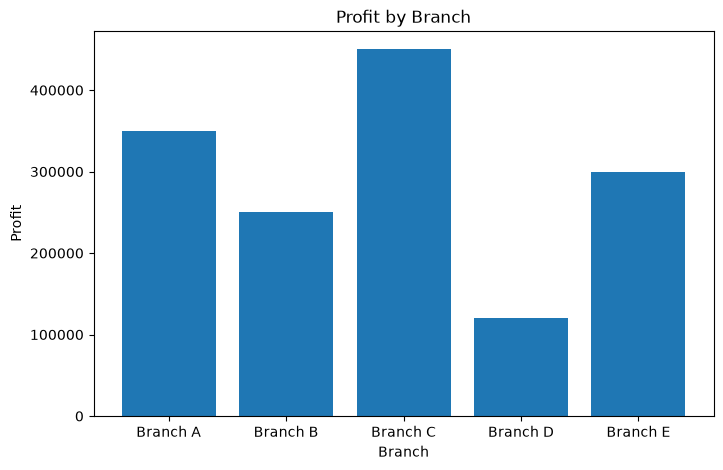

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(df["Branch_Name"], df["Profit"])

plt.title("Profit by Branch")
plt.xlabel("Branch")
plt.ylabel("Profit")

plt.show()

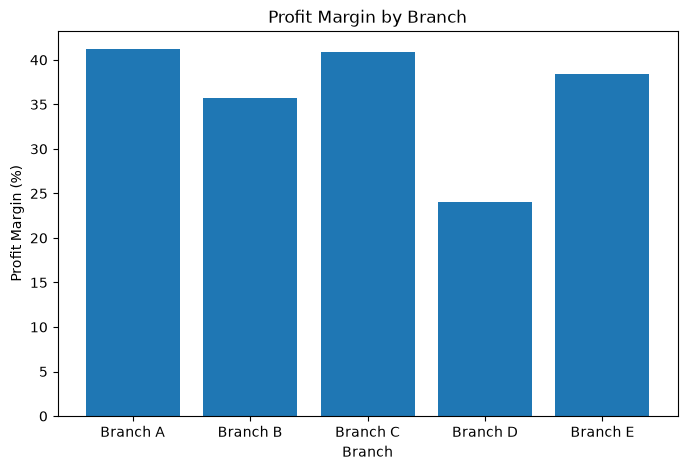

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(df["Branch_Name"], df["Profit_Margin"])

plt.title("Profit Margin by Branch")
plt.xlabel("Branch")
plt.ylabel("Profit Margin (%)")

plt.show()

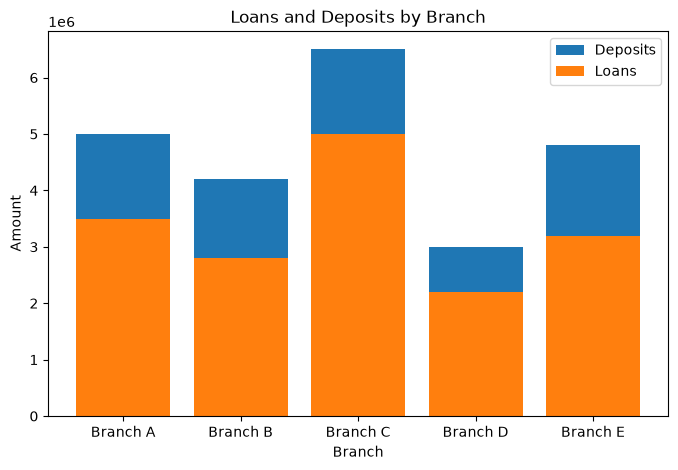

In [13]:
plt.figure(figsize=(8, 5))

plt.bar(df["Branch_Name"], df["Deposits"], label="Deposits")
plt.bar(df["Branch_Name"], df["Loans"], bottom=df["Deposits"] * 0)

plt.title("Loans and Deposits by Branch")
plt.xlabel("Branch")
plt.ylabel("Amount")

plt.legend(["Deposits", "Loans"])
plt.show()

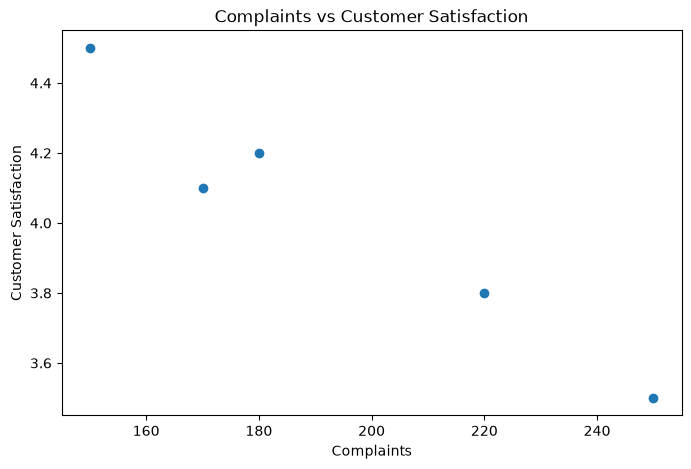

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Complaints"], df["Customer_Satisfaction"])

plt.title("Complaints vs Customer Satisfaction")
plt.xlabel("Complaints")
plt.ylabel("Customer Satisfaction")

plt.show()

In [15]:
branch_ranking = df[
    ["Branch_Name", "Profit", "Profit_Margin", "Customer_Satisfaction", "Complaints"]
].sort_values("Profit", ascending=False)

branch_ranking


,Branch_Name,Profit,Profit_Margin,Customer_Satisfaction,Complaints
2,Branch C,450000,40.909091,4.5,150
0,Branch A,350000,41.176471,4.2,180
4,Branch E,300000,38.461538,4.1,170
1,Branch B,250000,35.714286,3.8,220
3,Branch D,120000,24.000000,3.5,250


In [16]:
df["Performance_Score"] = (
    df["Profit_Margin"] * 0.35
    + df["Customer_Satisfaction"] * 10 * 0.30
    + (df["Revenue_per_Employee"] / df["Revenue_per_Employee"].max()) * 100 * 0.20
    + (df["Customers_per_Employee"] / df["Customers_per_Employee"].max()) * 100 * 0.15
)

df[["Branch_Name", "Performance_Score"]].sort_values(
    "Performance_Score", ascending=False
)


,Branch_Name,Performance_Score
2,Branch C,62.818182
0,Branch A,58.737017
4,Branch E,58.497902
1,Branch B,54.316268
3,Branch D,48.524242


In [17]:
df.to_csv("data/processed/branch_performance.csv", index=False)

print("Performance score saved successfully!")


Performance score saved successfully!


In [18]:
from src.nlp.sentiment import analyze_sentiment

print(analyze_sentiment("The staff was very helpful and friendly."))
print(analyze_sentiment("The waiting time was too long."))
print(analyze_sentiment("The service was okay."))

('Positive', 0.2875)
('Negative', -0.05)
('Positive', 0.5)
('Positive', 0.2875)
('Negative', -0.05)
('Positive', 0.5)


In [19]:
feedback = [
    "The staff was very helpful and friendly.",
    "The waiting time was too long.",
    "ATM was not working.",
    "Excellent service and quick response.",
    "The loan process was very slow.",
    "The branch staff was rude.",
    "I am satisfied with the service."
]

feedback_df = pd.DataFrame({
    "Feedback": feedback
})

feedback_df

,Feedback
0,The staff was very helpful and friendly.
1,The waiting time was too long.
2,ATM was not working.
3,Excellent service and quick response.
4,The loan process was very slow.
5,The branch staff was rude.
6,I am satisfied with the service.


In [20]:
feedback_df[["Sentiment", "Polarity"]] = feedback_df["Feedback"].apply(
    lambda x: pd.Series(analyze_sentiment(x))
)

feedback_df

,Feedback,Sentiment,Polarity
0,The staff was very helpful and friendly.,Positive,0.287500
1,The waiting time was too long.,Negative,-0.050000
2,ATM was not working.,Neutral,0.000000
3,Excellent service and quick response.,Positive,0.666667
4,The loan process was very slow.,Negative,-0.390000
5,The branch staff was rude.,Negative,-0.300000
6,I am satisfied with the service.,Positive,0.500000


In [21]:
feedback_df["Branch_ID"] = [101, 102, 103, 104, 105, 102, 101]

feedback_df

,Feedback,Sentiment,Polarity,Branch_ID
0,The staff was very helpful and friendly.,Positive,0.287500,101
1,The waiting time was too long.,Negative,-0.050000,102
2,ATM was not working.,Neutral,0.000000,103
3,Excellent service and quick response.,Positive,0.666667,104
4,The loan process was very slow.,Negative,-0.390000,105
5,The branch staff was rude.,Negative,-0.300000,102
6,I am satisfied with the service.,Positive,0.500000,101


In [22]:
branch_sentiment = (
    feedback_df
    .groupby("Branch_ID")["Sentiment"]
    .value_counts()
    .unstack(fill_value=0)
)

branch_sentiment

Sentiment,Positive,Negative,Neutral
Branch_ID,,,
101,2,0,0
102,0,2,0
103,0,0,1
104,1,0,0
105,0,1,0


In [23]:
df = df.merge(
    branch_sentiment,
    on="Branch_ID",
    how="left"
)

df

,Branch_ID,Branch_Name,Region,Customers,New_Customers,Deposits,Loans,Revenue,Expenses,Employees,...,Profit,Profit_Margin,Loan_to_Deposit_Ratio,Complaint_Rate,Revenue_per_Employee,Customers_per_Employee,Performance_Score,Positive,Negative,Neutral
0,101,Branch A,North,12000,1200,5000000,3500000,850000,500000,45,...,350000,41.176471,70.000000,1.500000,18888.888889,266.666667,58.737017,2,0,0
1,102,Branch B,South,9500,800,4200000,2800000,700000,450000,38,...,250000,35.714286,66.666667,2.315789,18421.052632,250.000000,54.316268,0,2,0
2,103,Branch C,East,15000,1800,6500000,5000000,1100000,650000,52,...,450000,40.909091,76.923077,1.000000,21153.846154,288.461538,62.818182,0,0,1
3,104,Branch D,West,8000,500,3000000,2200000,500000,380000,30,...,120000,24.000000,73.333333,3.125000,16666.666667,266.666667,48.524242,1,0,0
4,105,Branch E,North,11000,1000,4800000,3200000,780000,480000,40,...,300000,38.461538,66.666667,1.545455,19500.000000,275.000000,58.497902,0,1,0


In [24]:
df["Negative_Feedback_Rate"] = (
    df["Negative"] /
    (df["Positive"] + df["Negative"] + df["Neutral"])
) * 100

df[
    [
        "Branch_Name",
        "Positive",
        "Negative",
        "Neutral",
        "Negative_Feedback_Rate"
    ]
]


,Branch_Name,Positive,Negative,Neutral,Negative_Feedback_Rate
0,Branch A,2,0,0,0.0
1,Branch B,0,2,0,100.0
2,Branch C,0,0,1,0.0
3,Branch D,1,0,0,0.0
4,Branch E,0,1,0,100.0


In [25]:
df.to_csv(
    "data/processed/branch_performance_with_nlp.csv",
    index=False
)

print("NLP processed data saved successfully!")


NLP processed data saved successfully!


In [26]:
dashboard_data = df[
    [
        "Branch_ID",
        "Branch_Name",
        "Region",
        "Customers",
        "Deposits",
        "Loans",
        "Revenue",
        "Expenses",
        "Profit",
        "Profit_Margin",
        "Loan_to_Deposit_Ratio",
        "Customer_Satisfaction",
        "Complaints",
        "Revenue_per_Employee",
        "Customers_per_Employee",
        "Positive",
        "Negative",
        "Neutral",
        "Negative_Feedback_Rate",
        "Performance_Score"
    ]
].copy()

dashboard_data

,Branch_ID,Branch_Name,Region,Customers,Deposits,Loans,Revenue,Expenses,Profit,Profit_Margin,Loan_to_Deposit_Ratio,Customer_Satisfaction,Complaints,Revenue_per_Employee,Customers_per_Employee,Positive,Negative,Neutral,Negative_Feedback_Rate,Performance_Score
0,101,Branch A,North,12000,5000000,3500000,850000,500000,350000,41.176471,70.000000,4.2,180,18888.888889,266.666667,2,0,0,0.0,58.737017
1,102,Branch B,South,9500,4200000,2800000,700000,450000,250000,35.714286,66.666667,3.8,220,18421.052632,250.000000,0,2,0,100.0,54.316268
2,103,Branch C,East,15000,6500000,5000000,1100000,650000,450000,40.909091,76.923077,4.5,150,21153.846154,288.461538,0,0,1,0.0,62.818182
3,104,Branch D,West,8000,3000000,2200000,500000,380000,120000,24.000000,73.333333,3.5,250,16666.666667,266.666667,1,0,0,0.0,48.524242
4,105,Branch E,North,11000,4800000,3200000,780000,480000,300000,38.461538,66.666667,4.1,170,19500.000000,275.000000,0,1,0,100.0,58.497902
